# Synthetic-data demo

This notebook exercises the full modelling pipeline on **simulated** wrist-accelerometer data, so it runs anywhere without access to the study recordings:

1. Simulate day-long (15:00 → 15:00) tri-axial recordings with a known bedtime and wake time.
2. Run the button-press **label selection** (`click_candidates.select_clicks`) on a night with a spurious press.
3. Split nights by participant with `preprocessing.participant_folds` / `FoldFactory`.
4. Train `SleepModel` (TCN and transformer trunks, distribution vs. regression head) and compare localisation error.

The simulator is deliberately simple: it is a smoke test for the code, not a stand-in for the real data, and the numbers here say nothing about performance on real recordings. Everything is at 1-minute resolution (1440 samples/day) to keep it fast on a CPU.

In [1]:
import sys, warnings, logging
sys.path.insert(0, "..")          # repo root
warnings.filterwarnings("ignore")
for _name in ("pytorch_lightning", "pytorch_lightning.utilities.rank_zero",
              "lightning.pytorch", "lightning.pytorch.utilities.rank_zero",
              "lightning_fabric.utilities.seed"):
    logging.getLogger(_name).setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt

from click_candidates import select_clicks
from preprocessing import FoldFactory, participant_folds
from model import SleepModel

pl.seed_everything(0, workers=True, verbose=False)
torch.set_num_threads(max(1, torch.get_num_threads()))

## 1. Simulate recordings

Each night gets a bedtime drawn around the participant's chronotype and a sleep duration of 5–10 h. The signal is a unit gravity vector whose orientation performs a random walk scaled by an activity level:

* **awake** – high, bursty activity (participant-specific scale);
* **wind-down** – a 20–90 min low-activity period before bed (TV, reading), which makes the onset less trivial;
* **asleep** – near-still, with occasional posture changes and, on some nights, a brief awakening.

The bed press happens at bed onset and the wake press at wake onset.

In [2]:
T = 1440                       # minutes per recording (15:00 -> 15:00)
START_HOUR = 15

def simulate_day(rng, bed_h, sleep_h, activity, awakening):
    """One 24 h recording at 1-min resolution. Returns (signal (T,3), bed_min, wake_min)."""
    t = np.arange(T)
    bed_m = int(round(((bed_h - START_HOUR) % 24) * 60))
    wake_m = bed_m + int(round(sleep_h * 60))
    asleep = (t >= bed_m) & (t < wake_m)

    level = activity * np.exp(rng.normal(0, 0.5, T))
    level[(t >= bed_m - rng.integers(20, 90)) & (t < bed_m)] *= 0.35   # wind-down
    level[asleep] = 0.01 * activity
    if awakening:
        s = rng.integers(bed_m + 60, wake_m - 60)
        level[s:s + rng.integers(3, 12)] = 0.7 * activity

    theta = np.cumsum(rng.normal(0, level)) + 0.8
    phi = np.cumsum(rng.normal(0, level))
    jumps = asleep & (rng.random(T) < 1 / 60)                          # posture shifts
    theta += np.cumsum(jumps * rng.normal(0, 0.8, T))

    sig = np.stack([np.sin(theta) * np.cos(phi),
                    np.sin(theta) * np.sin(phi),
                    np.cos(theta)], axis=1)
    sig += rng.normal(0, 1, (T, 3)) * (0.005 + 0.3 * level[:, None])
    return sig.astype(np.float32), bed_m, wake_m


def simulate_cohort(n_participants=120, nights=(4, 9), seed=0):
    rng = np.random.default_rng(seed)
    X, y_bed, y_wake, pids, days = [], [], [], [], []
    t0 = np.datetime64("2024-01-01T15:00")
    for pid in range(n_participants):
        chrono = rng.normal(0, 0.75)                 # hours, participant offset
        activity = rng.uniform(0.15, 0.4)
        for d in range(rng.integers(*nights)):
            bed_h = float(np.clip(23 + chrono + rng.normal(0, 0.6), 20.5, 26.5)) % 24
            sleep_h = float(np.clip(rng.normal(7.5, 1.0), 5, 10))
            sig, b, w = simulate_day(rng, bed_h, sleep_h, activity, rng.random() < 0.4)
            X.append(sig)
            y_bed.append((START_HOUR + b / 60) % 24)
            y_wake.append((START_HOUR + w / 60) % 24)
            pids.append(pid)
            days.append((t0 + np.timedelta64(d, "D")).astype("datetime64[s]").astype(np.int64))
    return (torch.from_numpy(np.stack(X)).half(),
            torch.tensor(y_bed, dtype=torch.float32),
            torch.tensor(y_wake, dtype=torch.float32),
            torch.tensor(pids),
            torch.tensor(days, dtype=torch.float32))

X, y_bed, y_wake, pids, days = simulate_cohort()
print("X", tuple(X.shape), X.dtype, "| nights:", len(y_bed), "| participants:", len(pids.unique()))

X (726, 1440, 3) torch.float16 | nights: 726 | participants: 120


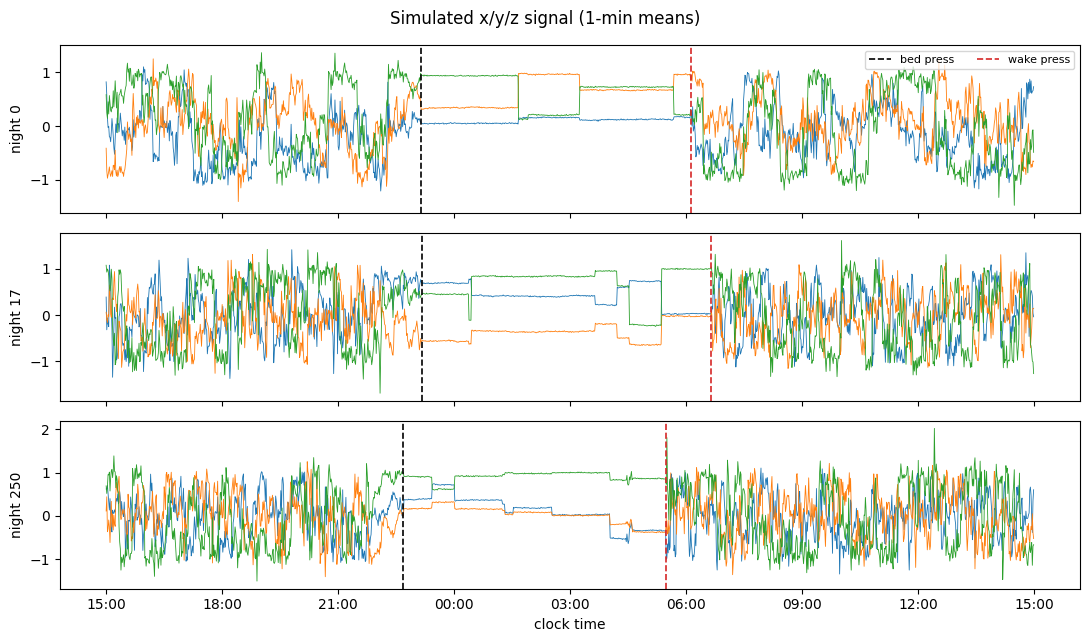

In [3]:
def clock(h):
    h = h % 24
    return f"{int(h):02d}:{int(round((h % 1) * 60)) % 60:02d}"

hours = START_HOUR + np.arange(T) / 60
fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
for ax, i in zip(axes, [0, 17, 250]):
    ax.plot(hours, X[i].float().numpy(), lw=0.6)
    for yv, c, lab in [(y_bed[i], "k", "bed press"), (y_wake[i], "tab:red", "wake press")]:
        ax.axvline(START_HOUR + (yv - START_HOUR) % 24, color=c, ls="--", lw=1.2, label=lab)
    ax.set_ylabel(f"night {i}")
axes[0].legend(loc="upper right", ncol=2, fontsize=8)
ticks = np.arange(15, 40, 3)
axes[-1].set_xticks(ticks, [clock(t) for t in ticks])
axes[-1].set_xlabel("clock time")
fig.suptitle("Simulated x/y/z signal (1-min means)")
plt.tight_layout()

## 2. Label selection from button presses

In the real data, labels come from the device's event button, and participants press it at odd times too. `select_clicks` scores every (bed, wake) press pair by the movement contrast between the enclosed interval and the 60-min flanks, and keeps the best pair. Here we add a spurious press in the middle of the night, offered both as a bed and a wake candidate — the case that breaks per-press scoring.

In [4]:
rng = np.random.default_rng(1)
sig, b, w = simulate_day(rng, bed_h=23.3, sleep_h=7.4, activity=0.3, awakening=True)
times = np.datetime64("2024-03-04T15:00", "ns") + np.arange(T).astype("timedelta64[m]")
spurious = b + 200                                           # ~02:40 press

bedtime, waketime, reason, diag = select_clicks(
    sig, times,
    bed_times=[times[b], times[spurious]],
    wake_times=[times[spurious], times[w]],
)
print("reason     :", reason)
print("selected   :", pd.Timestamp(bedtime).strftime("%H:%M"), "->", pd.Timestamp(waketime).strftime("%H:%M"))
print("true       :", pd.Timestamp(times[b]).strftime("%H:%M"), "->", pd.Timestamp(times[w]).strftime("%H:%M"))

(pd.DataFrame(diag)
   .assign(bedtime=lambda d: pd.to_datetime(d.bedtime).dt.strftime("%H:%M"),
           waketime=lambda d: pd.to_datetime(d.waketime).dt.strftime("%H:%M"))
   [["bedtime", "waketime", "tib_h", "contrast_bed", "contrast_wake", "valid", "why", "score"]]
   .round(2))

reason     : ok
selected   : 23:18 -> 06:42
true       : 23:18 -> 06:42


,bedtime,waketime,tib_h,contrast_bed,contrast_wake,valid,why,score
0,23:18,02:38,3.33,7.77,0.98,False,contrast,NaN
1,23:18,06:42,7.40,7.95,10.83,True,ok,4.46
2,02:38,02:38,0.00,NaN,NaN,False,duration,NaN
3,02:38,06:42,4.07,1.03,11.09,False,contrast,NaN


In [5]:
# How often is the correct pair recovered when a random mid-night press is added?
rng = np.random.default_rng(2)
hits = 0
n_trials = 300
for _ in range(n_trials):
    sig, b, w = simulate_day(rng, (23 + rng.normal(0, 1)) % 24,
                             float(np.clip(rng.normal(7.5, 1), 5, 10)),
                             rng.uniform(0.15, 0.4), rng.random() < 0.4)
    s = b + int((w - b) * rng.uniform(0.3, 0.7))
    bt, wt, _, _ = select_clicks(sig, times, [times[b], times[s]], [times[s], times[w]])
    hits += (bt == times[b]) and (wt == times[w])
print(f"correct pair recovered on {hits}/{n_trials} simulated nights")

correct pair recovered on 300/300 simulated nights


## 3. Participant-level folds

`participant_folds` assigns *participants* to folds so no person contributes nights to both training and test. `FoldFactory.get_fold(i)` uses fold `i` as test, fold `i+1` as validation, and normalises with training-set statistics only. We predict the **bedtime** press (the `"evening"` target, the default in `preprocessing.py`).

In [6]:
fold_idx = participant_folds(pids, n_folds=5, seed=0)
folds = FoldFactory(X, y_bed, pids, days, fold_idx, n_folds=5, batch_size=32, num_workers=0)
train_loader, val_loader, test_loader = folds.get_fold(0)

xb, yb, pb, db = next(iter(train_loader))
print("batch x:", tuple(xb.shape), xb.dtype, "| y:", tuple(yb.shape), "| example targets:", [clock(v) for v in yb[:4].tolist()])
assert not set(pids[fold_idx[0]].tolist()) & set(pids[np.concatenate(fold_idx[2:])].tolist()), "participant leak"

[fold 0] days train/val/test = 426/149/151
batch x: (32, 1440, 3) torch.float32 | y: (32,) | example targets: ['23:35', '23:45', '21:09', '22:23']


## 4. Train and compare heads / trunks

Settings for 1-minute data: `sample_rate = 1/60`, `seq_len = 1440`, `patch_len = 10` (10-minute patches → 144 positions). The distribution head is trained with soft-label cross-entropy against a Gaussian of width `label_sigma_min`; the regression head (ablation arm) predicts a single normalised position with an L1 loss.

In [9]:
COMMON = dict(in_channels=3, d_model=64, seq_len=T, patch_len=10, sample_rate=1 / 60,
              start_hour=START_HOUR, label_sigma_min=10, lr=1e-3, weight_decay=1e-4, dropout=0.1)

CONFIGS = {
    "TCN + distribution":         dict(temporal_model="tcn", num_channels=[64, 64, 64], kernel_size_tcn=3),
    "Transformer + distribution": dict(temporal_model="transformer", nhead=4, transformer_layers=2,
                                       transformer_ff_dim=128, use_pos_enc=True),
    "TCN + regression (L1)":      dict(temporal_model="tcn", num_channels=[64, 64, 64], kernel_size_tcn=3,
                                       head_type="regression", regression_loss="l1"),
}
MAX_EPOCHS = 1

def fit(cfg):
    pl.seed_everything(0, workers=True, verbose=False)
    model = SleepModel(**COMMON, **cfg)
    trainer = pl.Trainer(max_epochs=MAX_EPOCHS, accelerator="cpu", logger=False,
                         enable_checkpointing=False, enable_progress_bar=False,
                         enable_model_summary=False)
    trainer.fit(model, train_loader, val_loader)
    return model, trainer

def evaluate(model, loader):
    model.eval()
    preds, ys = [], []
    with torch.no_grad():
        for x, y, _, _ in loader:
            preds.append(model.predict_hours(x)); ys.append(y)
    preds, ys = torch.cat(preds), torch.cat(ys)
    diff = (preds - ys + 12) % 24 - 12                     # signed, wrap-safe, hours
    return preds, ys, diff.abs() * 60                      # error in minutes

models, results = {}, {}
for name, cfg in CONFIGS.items():
    model, _ = fit(cfg)
    _, _, err = evaluate(model, test_loader)
    models[name] = model
    results[name] = err
    print(f"{name:<28s} test MAE {err.mean():6.1f} min | median {err.median():6.1f} min")

TCN + distribution           test MAE  210.4 min | median  206.2 min
Transformer + distribution   test MAE   44.6 min | median   37.8 min
TCN + regression (L1)        test MAE  122.3 min | median  123.5 min


In [10]:
# Reference: predict the mean training bedtime for every night (circular mean).
train_idx = np.concatenate(fold_idx[2:])
ang = y_bed[train_idx] / 24 * 2 * np.pi
mean_h = (torch.atan2(ang.sin().mean(), ang.cos().mean()) / (2 * np.pi) * 24) % 24
y_test = y_bed[fold_idx[0]]
results["Mean bedtime (baseline)"] = (((mean_h - y_test + 12) % 24 - 12).abs() * 60)

summary = pd.DataFrame({
    name: {"MAE (min)": e.mean().item(), "median AE (min)": e.median().item(),
           "within 15 min": (e <= 15).float().mean().item(),
           "within 30 min": (e <= 30).float().mean().item()}
    for name, e in results.items()
}).T
summary.style.format({"MAE (min)": "{:.1f}", "median AE (min)": "{:.1f}",
                      "within 15 min": "{:.0%}", "within 30 min": "{:.0%}"})

,MAE (min),median AE (min),within 15 min,within 30 min
TCN + distribution,210.4,206.2,0%,0%
Transformer + distribution,44.6,37.8,21%,39%
TCN + regression (L1),122.3,123.5,5%,10%
Mean bedtime (baseline),44.8,36.6,20%,40%


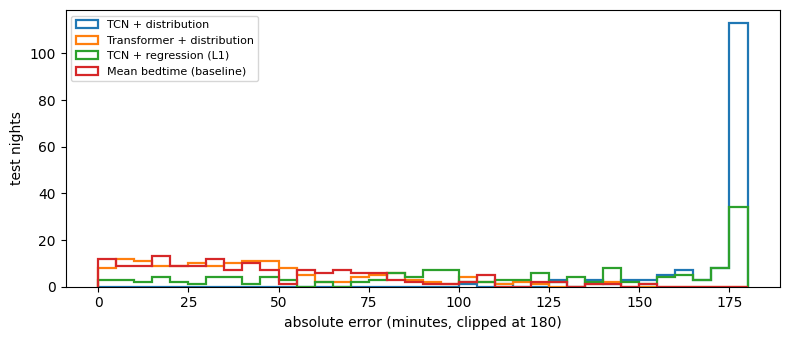

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0, 180, 37)
for name, e in results.items():
    ax.hist(e.clamp(max=180).numpy(), bins=bins, histtype="step", lw=1.6, label=name)
ax.set_xlabel("absolute error (minutes, clipped at 180)")
ax.set_ylabel("test nights")
ax.legend(fontsize=8)
plt.tight_layout()

## 5. What the distribution head sees

The distribution head outputs a probability over patch positions, which is decoded as its expectation (`calc_pred`) or as a local centre of mass around the mode (`calc_pred_local`). Plotting it next to the signal shows where the model places its mass.

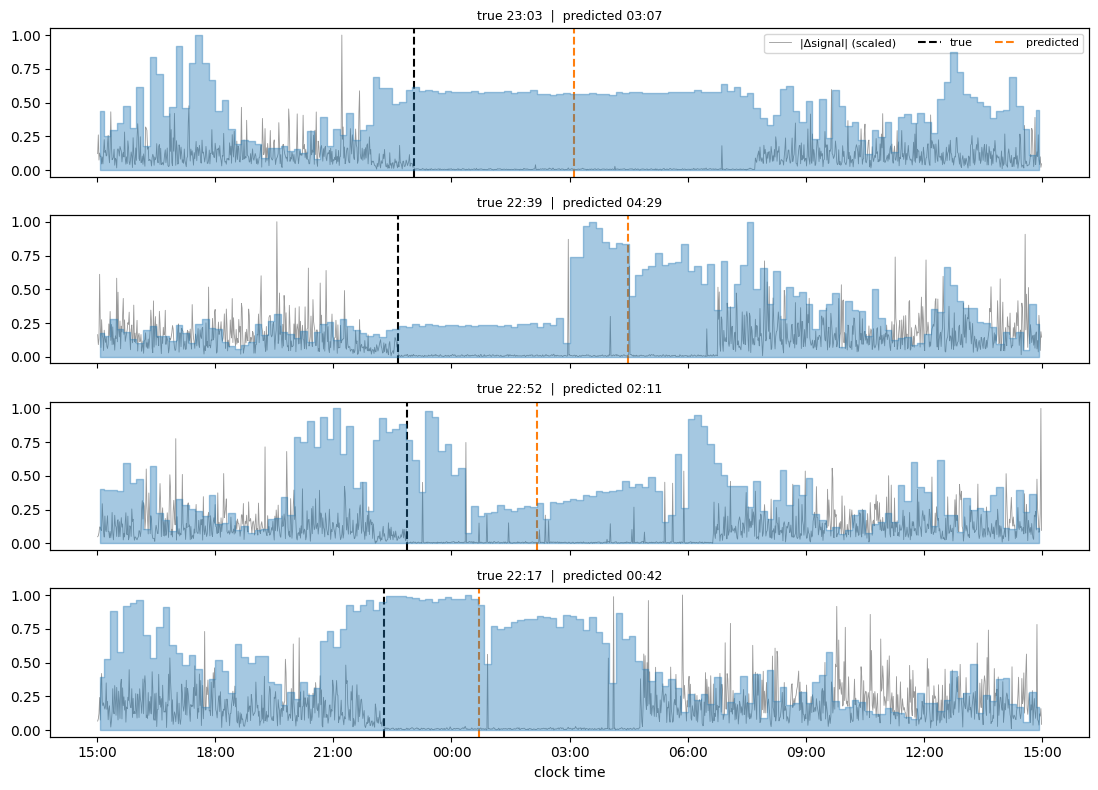

In [12]:
model = models["TCN + distribution"].eval()
x_test, y_test_b, _, _ = next(iter(test_loader))
with torch.no_grad():
    probs = torch.softmax(model(x_test), dim=1)
    pred_h = model.predict_hours(x_test)

patch_hours = START_HOUR + (np.arange(probs.shape[1]) * 10 + 5) / 60
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, i in zip(axes, range(4)):
    act = np.abs(np.diff(x_test[i].numpy(), axis=0)).mean(1)
    ax.plot(hours[1:], act / act.max(), color="0.6", lw=0.6, label="|Δsignal| (scaled)")
    ax2 = ax.twinx()
    ax2.fill_between(patch_hours, probs[i].numpy(), step="mid", alpha=0.4, color="tab:blue")
    ax2.set_yticks([])
    for yv, c, lab in [(y_test_b[i], "k", "true"), (pred_h[i], "tab:orange", "predicted")]:
        ax.axvline(START_HOUR + (float(yv) - START_HOUR) % 24, color=c, ls="--", lw=1.5, label=lab)
    ax.set_title(f"true {clock(float(y_test_b[i]))}  |  predicted {clock(float(pred_h[i]))}", fontsize=9)
axes[0].legend(loc="upper right", fontsize=8, ncol=3)
axes[-1].set_xticks(ticks, [clock(t) for t in ticks])
axes[-1].set_xlabel("clock time")
plt.tight_layout()

In [13]:
# The two decoders on the same logits
with torch.no_grad():
    logits = model(x_test)
    for name, fn in [("expectation (calc_pred)", model.calc_pred),
                     ("local centre of mass (calc_pred_local)", model.calc_pred_local)]:
        h = model.sample_to_hours(fn(logits))
        err = (((h - y_test_b + 12) % 24 - 12).abs() * 60)
        print(f"{name:<40s} MAE on this batch: {err.mean():.1f} min")

expectation (calc_pred)                  MAE on this batch: 228.2 min
local centre of mass (calc_pred_local)   MAE on this batch: 184.3 min


## Using your own data

Replace `simulate_cohort` with the cached tensors from `preprocessing.py`:

```python
from preprocessing import create_folds
folds = create_folds(None, freq_name="1min", target="evening", batch_size=32, num_workers=4)
train_loader, val_loader, test_loader = folds.get_fold(0)
```

and set `seq_len` / `sample_rate` to match the chosen resolution (e.g. `1440` / `1/60` for 1-min, `86400` / `1` for 1 Hz).